# Baseline Multilayer Perceptron (MLP)

In [56]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [57]:
# Standard library
import json

# Third-party libraries
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import geopandas as gpd

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Local imports
from src.mlp import (
    FlexibleMLP,
    build_optimizer,
    count_parameters,
    evaluate_regression,
    evaluate_regression_per_target,
    get_device,
    predict_mlp,
    set_seed,
    train_mlp,
)

# Plot configuration
plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "legend.frameon": True,
        "legend.borderpad": 0.3,
    }
)

# Reproducibility
SEED = 42

In [58]:
# Load data & artifacts
model_df = gpd.read_file("../data/processed/svi_counties.gpkg", layer="counties")

# Do not change row indices beyond this
X = pd.read_csv("../data/processed/X.csv")
X_log = pd.read_csv("../data/processed/X_log.csv")
y = pd.read_csv("../data/processed/y.csv")
fips = pd.read_csv("../data/processed/fips.csv")["FIPS"].astype(str).str.zfill(5)

with open("../data/processed/feature_titles.json") as f:
    feature_titles_log = json.load(f)

## Model Motivation

The multilayer perceptron (MLP) serves as the tabular deep learning baseline for this study. Its purpose is to establish a nonlinear benchmark for predicting county-level Social Vulnerability Index (SVI) theme rankings using the EP_* indicator features, without incorporating any explicit spatial structure.

An MLP is appropriate in this setting because the EP_* indicators represent multiple interrelated socioeconomic, demographic, and housing characteristics whose relationships with SVI outcomes may be nonlinear. Compared with linear regression models, the MLP can learn more flexible mappings between the feature matrix and the target variables while remaining conceptually simple and computationally efficient. At the same time, it still treats counties as independent observations, which provides a meaningful contrast with the graph neural network models.

## Model Formulation

Let $X \in \mathbb{R}^{n \times p}$ denote the feature matrix, where $n$ is the number of counties and $p = 16$ is the number of transformed EP_* predictor variables. Let $Y \in \mathbb{R}^{n \times q}$ denote the target matrix, where $q = 4$ corresponds to the four SVI theme rankings: `RPL_THEME1`, `RPL_THEME2`, `RPL_THEME3`, and `RPL_THEME4`.

The MLP defines a nonlinear mapping

$$
f_{\theta}: \mathbb{R}^{p} \rightarrow \mathbb{R}^{q},
$$

parameterized by weights and biases $\theta$, such that the predicted SVI themes are

$$
\hat{Y} = f_{\theta}(X).
$$

For the baseline model, the network consists of fully connected layers with **nonlinear activation functions (ReLU)** applied between hidden layers. For an input vector $x_i \in \mathbb{R}^{p}$, the forward pass can be written as

$$
h^{(1)}_i = \phi(W^{(1)} x_i + b^{(1)}),
$$

$$
h^{(2)}_i = \phi(W^{(2)} h^{(1)}_i + b^{(2)}),
$$

$$
\hat{y}_i = W^{(3)} h^{(2)}_i + b^{(3)},
$$

where $\phi(\cdot)$ is the activation function, $h^{(1)}_i$ and $h^{(2)}_i$ are hidden representations, and $\hat{y}_i \in \mathbb{R}^{4}$ is the predicted vector of SVI theme values for county $(i)$. Because the task is **multi-output regression**, the final layer is linear and produces continuous outputs.

Model parameters are estimated by minimizing a regression loss over the training data. Using mean squared error (MSE), the objective is

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^{n} \lVert y_i - \hat{y}_i \rVert_2^2.
$$

This formulation allows the MLP to learn shared nonlinear structure across the four SVI themes while predicting all targets jointly within a single model.

## Baseline Architecture

The baseline MLP uses a compact two-hidden-layer design:

$$
16 \rightarrow 64 \rightarrow 32 \rightarrow 4
$$

with ReLU activations and light dropout regularization between hidden layers as shown in @tbl-mlp-architecture. 

This baseline therefore acts as a strong tabular benchmark while preserving a clear methodological distinction between feature-only learning and later spatial graph-based learning.

## Ablation Plan

After establishing the baseline MLP, a series of controlled ablation experiments are conducted to evaluate how sensitive performance is to **architectural and preprocessing choices**. These ablations are designed to clarify whether any observed improvements arise from meaningful modeling decisions rather than arbitrary hyperparameter choices.

To ensure methodological rigor, **all model selection and hyperparameter tuning decisions are made using the validation split only**. The held-out test split is reserved exclusively for the final evaluation of the selected configuration. This separation prevents information leakage from the test data during model development and ensures that reported test performance reflects a true estimate of generalization.

Across all ablation experiments, both feature representations (standardized **raw EP_* features** and standardized **log-transformed EP_* features**) are evaluated. This ensures that architectural and regularization comparisons are not confounded by preprocessing choices.

Model configurations are compared primarily using **root mean squared error (RMSE)** on the validation set. In this multi-target setting, RMSE is computed across all predictions for the four SVI theme targets (**RPL_THEME1–RPL_THEME4**), effectively averaging the squared errors across both samples and targets before taking the square root. This provides a single summary measure of predictive error across the four SVI dimensions. **R² is also reported to provide complementary information about the proportion of variance explained**, but RMSE is used as the primary selection criterion for identifying the best configuration.

The main ablation directions are described below.

### Feature Representation

The first ablation compares **raw EP_* features** against the **log-transformed** motivated by the EDA. Log transformation reduces skewness and heavy-tailed behavior present in several socioeconomic indicators, which may improve optimization stability and predictive accuracy. Evaluating both representations across all model configurations allows us to determine whether this preprocessing step provides a consistent performance benefit.

### Network Capacity

The second ablation examines architectural complexity by comparing the **baseline two-layer MLP** with two deeper network variants (**Deep-128** and **Deep-256**). These variants progressively increase both width and depth of the hidden layers, enabling the model to capture more complex nonlinear interactions among socioeconomic indicators.

This experiment evaluates whether increasing representational capacity improves county-level SVI prediction or whether the simpler baseline architecture already captures the relevant relationships in the EP_* feature space.

### Regularization

The third ablation studies the effect of **dropout strength** and **weight decay**. These experiments evaluate whether the baseline architecture is under-regularized or over-regularized and help identify a configuration that balances predictive performance with model stability.

### Final Model Evaluation

After completing the ablation experiments, the **best-performing configuration identified using validation performance** is selected as the final MLP baseline. This configuration is then evaluated **once on the held-out test split**, which has not been used during any stage of hyperparameter tuning or model selection. The resulting test metrics provide an unbiased estimate of the model’s ability to generalize to unseen counties.

Together, these ablations provide a structured and reproducible framework for assessing the robustness of the MLP baseline before moving to graph-based models such as the Graph Convolutional Network (GCN).

In [59]:
# Split X and y with fips to maintain row indices for downstream GCN models

# First split: train vs temp (val + test) = 70/30
X_train, X_temp, Xlog_train, Xlog_temp, y_train, y_temp, fips_train, fips_temp = train_test_split(
    X,
    X_log,
    y,
    fips,
    test_size=0.30,
    random_state=SEED
)

# Second split: validation vs test = 15/15
X_val, X_test, Xlog_val, Xlog_test, y_val, y_test, fips_val, fips_test = train_test_split(
    X_temp,
    Xlog_temp,
    y_temp,
    fips_temp,
    test_size=0.50,
    random_state=SEED
)

In [60]:
# Scale X splits on train
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scale X_log splits on train
scaler_Xlog = StandardScaler()

Xlog_train_scaled = scaler_Xlog.fit_transform(Xlog_train)
Xlog_val_scaled = scaler_Xlog.transform(Xlog_val)
Xlog_test_scaled = scaler_Xlog.transform(Xlog_test)

# Scale y splits on train
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

In [61]:
#| output: false

# Data Validation
split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Samples": [
        X_train.shape[0],
        X_val.shape[0],
        X_test.shape[0]
    ],
    "Feature Count (X)": [
        X_train.shape[1],
        X_val.shape[1],
        X_test.shape[1]
    ],
    "Target Count (y)": [
        y_train.shape[1],
        y_val.shape[1],
        y_test.shape[1]
    ]
})

display(split_summary.style.hide(axis="index"))

Dataset,Samples,Feature Count (X),Target Count (y)
Train,2200,16,4
Validation,472,16,4
Test,472,16,4


In [62]:
#| output: false

# Data Validation
scale_check = pd.DataFrame({
    "Variable Group": ["Raw Features (X)", "Log-Transformed Features (X_log)", "Targets (y)"],
    "Training Mean (≈0)": [
        round(X_train_scaled.mean(), 4),
        round(Xlog_train_scaled.mean(), 4),
        round(y_train_scaled.mean(), 4)
    ],
    "Training Std (≈1)": [
        round(X_train_scaled.std(), 4),
        round(Xlog_train_scaled.std(), 4),
        round(y_train_scaled.std(), 4)
    ]
})

display(scale_check.style.hide(axis="index"))

Variable Group,Training Mean (≈0),Training Std (≈1)
Raw Features (X),0.000000,1.000000
Log-Transformed Features (X_log),-0.000000,1.000000
Targets (y),-0.000000,1.000000


In [63]:
#| output: false

# Raw feature tensors
Xraw_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
Xraw_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
Xraw_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)

# Log-transformed feature tensors
Xlog_train_t = torch.tensor(Xlog_train_scaled, dtype=torch.float32)
Xlog_val_t   = torch.tensor(Xlog_val_scaled, dtype=torch.float32)
Xlog_test_t  = torch.tensor(Xlog_test_scaled, dtype=torch.float32)

# Target tensors
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32)

# Data Validation
tensor_shapes = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Raw Feature Tensor Shape": [
        tuple(Xraw_train_t.shape),
        tuple(Xraw_val_t.shape),
        tuple(Xraw_test_t.shape)
    ],
    "Log Feature Tensor Shape": [
        tuple(Xlog_train_t.shape),
        tuple(Xlog_val_t.shape),
        tuple(Xlog_test_t.shape)
    ],
    "Target Tensor Shape": [
        tuple(y_train_t.shape),
        tuple(y_val_t.shape),
        tuple(y_test_t.shape)
    ]
})

display(tensor_shapes.style.hide(axis="index"))

Dataset,Raw Feature Tensor Shape,Log Feature Tensor Shape,Target Tensor Shape
Train,"(2200, 16)","(2200, 16)","(2200, 4)"
Validation,"(472, 16)","(472, 16)","(472, 4)"
Test,"(472, 16)","(472, 16)","(472, 4)"


### Feature Representation Ablation

The dataset was partitioned into train, validation, and test splits of 2200, 472, and 472 counties respectively, with a batch size of 64 across both pipelines (@tbl-mlp-dataloader-summary). Both pipelines used the same conservative MLP architecture consisting of **two hidden layers (64 → 32)** with ReLU activations and light dropout regularization (@tbl-mlp-architecture). The model predicts the four SVI theme targets simultaneously as a **multi-output regression problem**, allowing the network to learn shared structure across vulnerability dimensions while maintaining separate prediction targets.

In [64]:
#| label: tbl-mlp-dataloader-summary
#| tbl-cap: "Summary of TensorDataset and DataLoader configurations."

# Set batch size
BATCH_SIZE = 64

# Raw feature datasets/loaders
train_ds_raw = TensorDataset(Xraw_train_t, y_train_t)
val_ds_raw   = TensorDataset(Xraw_val_t, y_val_t)
test_ds_raw  = TensorDataset(Xraw_test_t, y_test_t)

train_loader_raw = DataLoader(train_ds_raw, batch_size=BATCH_SIZE, shuffle=True)
val_loader_raw   = DataLoader(val_ds_raw, batch_size=BATCH_SIZE, shuffle=False)
test_loader_raw  = DataLoader(test_ds_raw, batch_size=BATCH_SIZE, shuffle=False)

# Log feature datasets/loaders
train_ds_log = TensorDataset(Xlog_train_t, y_train_t)
val_ds_log   = TensorDataset(Xlog_val_t, y_val_t)
test_ds_log  = TensorDataset(Xlog_test_t, y_test_t)

train_loader_log = DataLoader(train_ds_log, batch_size=BATCH_SIZE, shuffle=True)
val_loader_log   = DataLoader(val_ds_log, batch_size=BATCH_SIZE, shuffle=False)
test_loader_log  = DataLoader(test_ds_log, batch_size=BATCH_SIZE, shuffle=False)

dataloader_summary = pd.DataFrame({
    "Pipeline": [
        "Raw Features",
        "Raw Features",
        "Raw Features",
        "Log-Transformed Features",
        "Log-Transformed Features",
        "Log-Transformed Features"
    ],
    "Dataset": [
        "Train", "Validation", "Test",
        "Train", "Validation", "Test"
    ],
    "Samples": [
        len(train_ds_raw), len(val_ds_raw), len(test_ds_raw),
        len(train_ds_log), len(val_ds_log), len(test_ds_log)
    ],
    "Batch Size": [BATCH_SIZE] * 6,
    "Num Batches": [
        len(train_loader_raw), len(val_loader_raw), len(test_loader_raw),
        len(train_loader_log), len(val_loader_log), len(test_loader_log)
    ],
})

display(dataloader_summary.style.hide(axis="index"))

Pipeline,Dataset,Samples,Batch Size,Num Batches
Raw Features,Train,2200,64,35
Raw Features,Validation,472,64,8
Raw Features,Test,472,64,8
Log-Transformed Features,Train,2200,64,35
Log-Transformed Features,Validation,472,64,8
Log-Transformed Features,Test,472,64,8


In [65]:
#| label: tbl-mlp-runtime-config
#| tbl-cap: "Runtime configuration for the baseline MLP experiments."
#| output: false

# Set initial constants
SEED = 42
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 300
PATIENCE = 25

set_seed(SEED)
device = get_device()
criterion = nn.MSELoss()

# Runtime validation
runtime_config = pd.DataFrame({
    "Setting": [
        "Random Seed",
        "Device",
        "Loss Function",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        SEED,
        str(device),
        "MSELoss",
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(runtime_config.style.hide(axis="index"))

Setting,Value
Random Seed,42
Device,cpu
Loss Function,MSELoss
Learning Rate,0.001000
Weight Decay,0.000100
Max Epochs,300
Early Stopping Patience,25


In [66]:
#| label: tbl-mlp-architecture
#| tbl-cap: "Baseline MLP architectures for the raw-feature and log-transformed-feature pipelines."

mlp_raw = FlexibleMLP(
    input_dim=Xraw_train_t.shape[1],
    hidden_dims=[64, 32],
    output_dim=y_train_t.shape[1],
    dropout=0.1,
)

mlp_log = FlexibleMLP(
    input_dim=Xlog_train_t.shape[1],
    hidden_dims=[64, 32],
    output_dim=y_train_t.shape[1],
    dropout=0.1,
)

params_raw = count_parameters(mlp_raw)
params_log = count_parameters(mlp_log)

mlp_architecture = pd.DataFrame({
    "Component": [
        "Input Dimension",
        "Hidden Dimensions",
        "Dropout",
        "Output Dimension",
        "Trainable Parameters"
    ],
    "Raw Features": [
        Xraw_train_t.shape[1],
        str([64, 32]),
        0.1,
        y_train_t.shape[1],
        params_raw
    ],
    "Log-Transformed Features": [
        Xlog_train_t.shape[1],
        str([64, 32]),
        0.1,
        y_train_t.shape[1],
        params_log
    ]
})

display(mlp_architecture.style.hide(axis="index"))

Component,Raw Features,Log-Transformed Features
Input Dimension,16,16
Hidden Dimensions,"[64, 32]","[64, 32]"
Dropout,0.100000,0.100000
Output Dimension,4,4
Trainable Parameters,3300,3300


In [67]:
#| label: tbl-mlp-training-config
#| tbl-cap: "Training configuration for the raw-feature and log-transformed-feature baseline MLP pipelines."
#| output: false

optimizer_raw = build_optimizer(
    model=mlp_raw,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

optimizer_log = build_optimizer(
    model=mlp_log,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Pre-training validation
training_config = pd.DataFrame({
    "Parameter": [
        "Optimizer",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience",
        "Training Loader",
        "Validation Loader",
        "Test Loader"
    ],
    "Raw Features": [
        "Adam",
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE,
        "train_loader_raw",
        "val_loader_raw",
        "test_loader_raw"
    ],
    "Log-Transformed Features": [
        "Adam",
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE,
        "train_loader_log",
        "val_loader_log",
        "test_loader_log"
    ]
})

display(training_config.style.hide(axis="index"))

Parameter,Raw Features,Log-Transformed Features
Optimizer,Adam,Adam
Learning Rate,0.001000,0.001000
Weight Decay,0.000100,0.000100
Max Epochs,300,300
Early Stopping Patience,25,25
Training Loader,train_loader_raw,train_loader_log
Validation Loader,val_loader_raw,val_loader_log
Test Loader,test_loader_raw,test_loader_log


In [68]:
# Model training for raw & log on val
mlp_raw, history_raw, best_epoch_raw, best_val_raw = train_mlp(
    model=mlp_raw,
    train_loader=train_loader_raw,
    val_loader=val_loader_raw,
    criterion=criterion,
    optimizer=optimizer_raw,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=device,
)

mlp_log, history_log, best_epoch_log, best_val_log = train_mlp(
    model=mlp_log,
    train_loader=train_loader_log,
    val_loader=val_loader_log,
    criterion=criterion,
    optimizer=optimizer_log,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=device,
)

In [69]:
#| label: tbl-mlp-training-summary
#| tbl-cap: "Training summary for the raw-feature and log-transformed-feature baseline MLP pipelines."
#| output: false

training_summary = pd.DataFrame({
    "Metric": [
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss"
    ],
    "Raw Features": [
        len(history_raw["epoch"]),
        best_epoch_raw,
        round(best_val_raw, 6)
    ],
    "Log-Transformed Features": [
        len(history_log["epoch"]),
        best_epoch_log,
        round(best_val_log, 6)
    ]
})

display(training_summary.style.hide(axis="index"))

Metric,Raw Features,Log-Transformed Features
Epochs Trained,300.000000,237.000000
Best Epoch,300.000000,212.000000
Best Validation Loss,0.019239,0.018318


Training behavior for the two pipelines was broadly similar. As shown in the learning curves (@fig-mlp-learning-curves), both models converged smoothly with steadily decreasing training and validation losses, suggesting stable optimization and limited overfitting. However, the **log-transformed feature pipeline consistently achieved lower validation loss throughout training**, indicating that the transformation produced a feature space that was easier for the neural network to learn from.

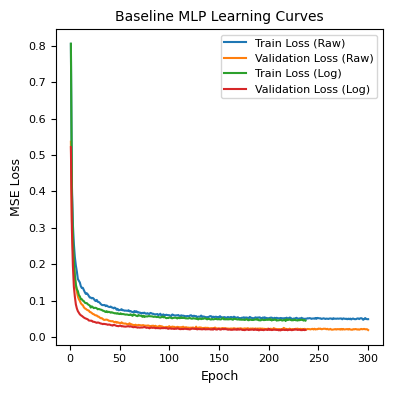

In [70]:
#| label: fig-mlp-learning-curves
#| fig-cap: "Training and validation loss curves for the raw-feature and log-transformed-feature baseline MLP pipelines."

plt.figure(figsize=(4, 4))

plt.plot(history_raw["epoch"], history_raw["train_loss"], label="Train Loss (Raw)")
plt.plot(history_raw["epoch"], history_raw["val_loss"], label="Validation Loss (Raw)")
plt.plot(history_log["epoch"], history_log["train_loss"], label="Train Loss (Log)")
plt.plot(history_log["epoch"], history_log["val_loss"], label="Validation Loss (Log)")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Baseline MLP Learning Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Target order
target_names = ["RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]

# MLP predictions
y_pred_raw_scaled = predict_mlp(mlp_raw, val_loader_raw, device=device)
y_pred_log_scaled = predict_mlp(mlp_log, val_loader_log, device=device)

# Reverse scaling for original scale
y_val_np = y_val_scaled
y_pred_raw = scaler_y.inverse_transform(y_pred_raw_scaled)
y_pred_log = scaler_y.inverse_transform(y_pred_log_scaled)
y_val_true = scaler_y.inverse_transform(y_val_np)

# Evaluate for average RMSE & R2
overall_raw = evaluate_regression(y_val_true, y_pred_raw)
overall_log = evaluate_regression(y_val_true, y_pred_log)

# Evaluate for RMSE & R2 per theme
per_target_raw = evaluate_regression_per_target(y_val_true, y_pred_raw, target_names)
per_target_log = evaluate_regression_per_target(y_val_true, y_pred_log, target_names)

The quantitative results confirm this pattern. On the validation set (@tbl-mlp-val-metrics-overall), the log-transformed features achieved a slightly lower **overall RMSE (0.0392 vs. 0.0412)** and a marginally higher **overall R² (0.9815 vs. 0.9806)** compared with the raw feature pipeline. Although the improvement is modest, the consistency across metrics suggests that log transformation helps stabilize the distribution of several skewed socioeconomic indicators.

In [72]:
#| label: tbl-mlp-val-metrics-overall
#| tbl-cap: "Overall and per-target validation-set regression metrics for the raw-feature and log-transformed-feature baseline MLP pipelines. Metrics are reported using RMSE and R² to summarize prediction error and variance explained."

rows = []

# Overall metrics
rows.append({
    "Metric": "Overall RMSE",
    "Raw Features": round(overall_raw["rmse"], 6),
    "Log-Transformed Features": round(overall_log["rmse"], 6)
})

rows.append({
    "Metric": "Overall R²",
    "Raw Features": round(overall_raw["r2"], 6),
    "Log-Transformed Features": round(overall_log["r2"], 6)
})

# Per-target metrics
for target in target_names:
    rows.append({
        "Metric": f"{target} RMSE",
        "Raw Features": round(per_target_raw[target]["rmse"], 6),
        "Log-Transformed Features": round(per_target_log[target]["rmse"], 6)
    })
    
    rows.append({
        "Metric": f"{target} R²",
        "Raw Features": round(per_target_raw[target]["r2"], 6),
        "Log-Transformed Features": round(per_target_log[target]["r2"], 6)
    })

overall_metrics = pd.DataFrame(rows)

display(overall_metrics.style.hide(axis="index"))

Metric,Raw Features,Log-Transformed Features
Overall RMSE,0.040191,0.039211
Overall R²,0.980607,0.981541
RPL_THEME1 RMSE,0.034082,0.032435
RPL_THEME1 R²,0.986023,0.987341
RPL_THEME2 RMSE,0.055576,0.053243
RPL_THEME2 R²,0.961449,0.964617
RPL_THEME3 RMSE,0.022016,0.022740
RPL_THEME3 R²,0.994202,0.993814
RPL_THEME4 RMSE,0.041548,0.041783
RPL_THEME4 R²,0.980008,0.979782


Per-theme performance further clarifies how the transformation affects the prediction task. The grouped RMSE comparison (@fig-mlp-per-theme-rmse-grouped) shows that the log-transformed pipeline slightly improves predictive accuracy for Theme 1 (Socioeconomic Status), while Theme 2 (Household Characteristics) experiences a small increase in error relative to the raw feature pipeline. Theme 3 (Minority Status) remains the easiest target to predict, with very low error for both representations and only a marginal difference between them. Theme 4 (Housing and Transportation) shows nearly identical performance across pipelines, indicating that the log transformation provides little additional benefit for this group of variables. Overall, the differences across themes are modest, suggesting that the transformation primarily affects a subset of skewed socioeconomic indicators while leaving other dimensions largely unchanged.

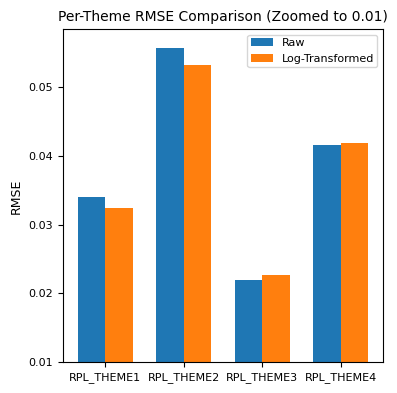

In [73]:
#| label: fig-mlp-per-theme-rmse-grouped
#| fig-cap: "Grouped comparison of per-theme RMSE on the validation set for the raw-feature and log-transformed-feature baseline MLP pipelines."

x = np.arange(len(target_names))
width = 0.35

raw_vals = [per_target_raw[t]["rmse"] for t in target_names]
log_vals = [per_target_log[t]["rmse"] for t in target_names]

plt.figure(figsize=(4, 4))
plt.bar(x - width/2, raw_vals, width, label="Raw")
plt.bar(x + width/2, log_vals, width, label="Log-Transformed")

plt.xticks(x, target_names)
plt.ylabel("RMSE")
plt.title("Per-Theme RMSE Comparison (Zoomed to 0.01)")
plt.ylim(0.01)
plt.legend()
plt.tight_layout()
plt.show()

The R² comparison across themes (@fig-mlp-per-theme-r2-grouped) shows a similar pattern. The log-transformed pipeline yields slightly higher explanatory power for Themes 1 and 2 while maintaining comparable performance for Themes 3 and 4. Across all themes, R² values remain very high (>0.96), indicating that the baseline MLP is already capturing the majority of variation in the SVI percentile theme targets.

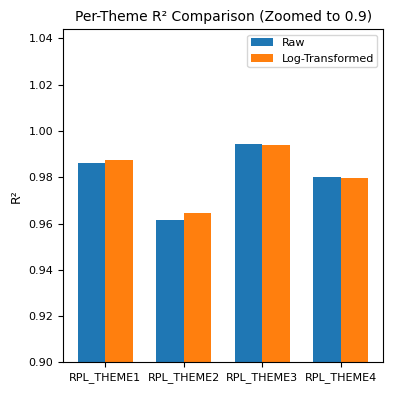

In [74]:
#| label: fig-mlp-per-theme-r2-grouped
#| fig-cap: "Grouped comparison of per-theme R² on the validation set for the raw-feature and log-transformed-feature baseline MLP pipelines."

x = np.arange(len(target_names))
width = 0.35

raw_vals = [per_target_raw[t]["r2"] for t in target_names]
log_vals = [per_target_log[t]["r2"] for t in target_names]

plt.figure(figsize=(4, 4))

plt.bar(x - width/2, raw_vals, width, label="Raw")
plt.bar(x + width/2, log_vals, width, label="Log-Transformed")

plt.xticks(x, target_names)
plt.ylabel("R²")
plt.title("Per-Theme R² Comparison (Zoomed to 0.9)")

plt.ylim(0.9)

plt.legend()
plt.tight_layout()
plt.show()

Taken together, the feature ablation suggests that **log transformation provides a modest but consistent improvement in predictive stability for Theme 1 and 2** which were dominated by skewed socioeconomic indicators. These results indicate that modeling social vulnerability benefits from accounting for the heavy-tailed distribution of many socioeconomic indicators. Transforming these variables helps reduce the influence of extreme counties and allows the neural network to learn relationships that generalize more consistently across the full range of vulnerability conditions.

## Architecture Ablation

To examine the role of model capacity, an architecture ablation was conducted comparing three MLP configurations of increasing depth and width: the current **baseline architecture (64 → 32)**, a **Deep-128 architecture (128 → 64 → 32)**, and a **Deep-256 architecture (256 → 128 → 64 → 32)** (@tbl-mlp-architecture-ablation-config).

In [75]:
#| label: tbl-mlp-architecture-ablation-config
#| tbl-cap: "Architecture configurations used in the MLP ablation study. The baseline, deep-128, and deep-256 variants are evaluated using both standardized raw and log-transformed features."

architecture_configs = {
    "Baseline": [64, 32],
    "Deep-128": [128, 64, 32],
    "Deep-256": [256, 128, 64, 32],
}

architecture_config_df = pd.DataFrame({
    "Setting": [
        "Baseline Hidden Dimensions",
        "Deep-128 Hidden Dimensions",
        "Deep-256 Hidden Dimensions",
        "Dropout",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        str(architecture_configs["Baseline"]),
        str(architecture_configs["Deep-128"]),
        str(architecture_configs["Deep-256"]),
        0.1,
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(architecture_config_df.style.hide(axis="index"))

Setting,Value
Baseline Hidden Dimensions,"[64, 32]"
Deep-128 Hidden Dimensions,"[128, 64, 32]"
Deep-256 Hidden Dimensions,"[256, 128, 64, 32]"
Dropout,0.100000
Learning Rate,0.001000
Weight Decay,0.000100
Max Epochs,300
Early Stopping Patience,25


In [76]:
target_names = ["RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]

architecture_results = []

# Training loop
for architecture_name, hidden_dims in architecture_configs.items():
    for feature_name, X_train_tensor, train_loader, val_loader in [
        ("Raw Features", Xraw_train_t, train_loader_raw, val_loader_raw),
        ("Log-Transformed Features", Xlog_train_t, train_loader_log, val_loader_log),
    ]:
        set_seed(SEED)

        model = FlexibleMLP(
            input_dim=X_train_tensor.shape[1],
            hidden_dims=hidden_dims,
            output_dim=y_train_t.shape[1],
            dropout=0.1,
        )

        optimizer = build_optimizer(
            model=model,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )

        model, history, best_epoch, best_val_loss = train_mlp(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        y_pred_scaled = predict_mlp(model, val_loader, device=device)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_val_scaled)

        overall_metrics = evaluate_regression(y_true, y_pred)
        per_target_metrics = evaluate_regression_per_target(y_true, y_pred, target_names)

        architecture_results.append({
            "Architecture": architecture_name,
            "Feature Pipeline": feature_name,
            "Hidden Dimensions": str(hidden_dims),
            "Dropout": 0.1,
            "Weight Decay": WEIGHT_DECAY,
            "Trainable Parameters": count_parameters(model),
            "Epochs Trained": len(history["epoch"]),
            "Best Epoch": best_epoch,
            "Best Validation Loss": best_val_loss,
            "Overall RMSE": overall_metrics["rmse"],
            "Overall R²": overall_metrics["r2"],
            "RPL_THEME1 RMSE": per_target_metrics["RPL_THEME1"]["rmse"],
            "RPL_THEME1 R²": per_target_metrics["RPL_THEME1"]["r2"],
            "RPL_THEME2 RMSE": per_target_metrics["RPL_THEME2"]["rmse"],
            "RPL_THEME2 R²": per_target_metrics["RPL_THEME2"]["r2"],
            "RPL_THEME3 RMSE": per_target_metrics["RPL_THEME3"]["rmse"],
            "RPL_THEME3 R²": per_target_metrics["RPL_THEME3"]["r2"],
            "RPL_THEME4 RMSE": per_target_metrics["RPL_THEME4"]["rmse"],
            "RPL_THEME4 R²": per_target_metrics["RPL_THEME4"]["r2"],
            "History": history,
            "Model": model
        })

In [77]:
#| label: tbl-mlp-architecture-ablation
#| tbl-cap: "Architecture ablation results for the MLP benchmark using standardized raw and log-transformed features. Performance is summarized using overall RMSE and R² on the validation set."
#| output: false

architecture_results_df = pd.DataFrame(architecture_results)

architecture_summary = architecture_results_df[
    [
        "Architecture",
        "Feature Pipeline",
        "Hidden Dimensions",
        "Trainable Parameters",
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss",
        "Overall RMSE",
        "Overall R²"
    ]
].copy()

architecture_summary["Best Validation Loss"] = architecture_summary["Best Validation Loss"].round(6)
architecture_summary["Overall RMSE"] = architecture_summary["Overall RMSE"].round(6)
architecture_summary["Overall R²"] = architecture_summary["Overall R²"].round(6)

# Create experiment labels
architecture_summary["Experiment"] = (
    architecture_summary["Architecture"] + " | " + architecture_summary["Feature Pipeline"]
)

architecture_summary = architecture_summary.drop(
    columns=["Architecture", "Feature Pipeline"]
)

architecture_summary = architecture_summary.set_index("Experiment").T

display(architecture_summary)

Experiment,Baseline | Raw Features,Baseline | Log-Transformed Features,Deep-128 | Raw Features,Deep-128 | Log-Transformed Features,Deep-256 | Raw Features,Deep-256 | Log-Transformed Features
Hidden Dimensions,"[64, 32]","[64, 32]","[128, 64, 32]","[128, 64, 32]","[256, 128, 64, 32]","[256, 128, 64, 32]"
Trainable Parameters,3300,3300,12644,12644,47716,47716
Epochs Trained,257,250,210,239,221,300
Best Epoch,232,225,185,214,196,292
Best Validation Loss,0.020694,0.019025,0.015814,0.016094,0.014076,0.013571
Overall RMSE,0.041689,0.039957,0.036414,0.036742,0.034361,0.033744
Overall R²,0.979134,0.980832,0.98408,0.983793,0.985825,0.98633


In [78]:
#| label: tbl-mlp-architecture-ablation-per-theme
#| tbl-cap: "Per-theme performance for the MLP architecture ablation study using standardized raw and log-transformed features. Metrics are reported as RMSE and R² for each SVI theme."
#| output: false

architecture_per_theme = architecture_results_df[
    [
        "Architecture",
        "Feature Pipeline",
        "RPL_THEME1 RMSE", "RPL_THEME1 R²",
        "RPL_THEME2 RMSE", "RPL_THEME2 R²",
        "RPL_THEME3 RMSE", "RPL_THEME3 R²",
        "RPL_THEME4 RMSE", "RPL_THEME4 R²",
    ]
].copy()

for col in architecture_per_theme.columns:
    if "RMSE" in col or "R²" in col:
        architecture_per_theme[col] = architecture_per_theme[col].round(6)

display(architecture_per_theme.style.hide(axis="index"))

Architecture,Feature Pipeline,RPL_THEME1 RMSE,RPL_THEME1 R²,RPL_THEME2 RMSE,RPL_THEME2 R²,RPL_THEME3 RMSE,RPL_THEME3 R²,RPL_THEME4 RMSE,RPL_THEME4 R²
Baseline,Raw Features,0.035369,0.984948,0.058036,0.957960,0.024904,0.992581,0.041385,0.980165
Baseline,Log-Transformed Features,0.032912,0.986966,0.054057,0.963526,0.022729,0.993820,0.043178,0.978409
Deep-128,Raw Features,0.032543,0.987257,0.046245,0.973307,0.022672,0.993851,0.039905,0.981559
Deep-128,Log-Transformed Features,0.030856,0.988544,0.047092,0.972320,0.026087,0.991859,0.039365,0.982055
Deep-256,Raw Features,0.029080,0.989825,0.043937,0.975905,0.024868,0.992602,0.036445,0.984618
Deep-256,Log-Transformed Features,0.029015,0.989871,0.043581,0.976294,0.024441,0.992854,0.034871,0.985918


The results show a clear and consistent relationship between network capacity and predictive performance. As illustrated in the RMSE comparison (@fig-mlp-architecture-ablation-rmse), prediction error steadily decreases as model depth and width increase. The baseline architecture produces the largest error across both feature pipelines, while the Deep-128 model yields a noticeable improvement. The **Deep-256 architecture achieves the lowest overall RMSE**, indicating that the additional nonlinear capacity allows the network to capture more complex interactions among socioeconomic, demographic, and housing indicators.

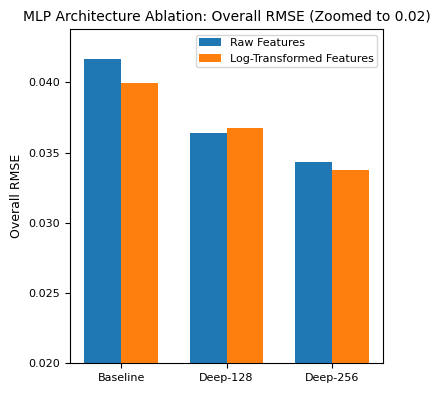

In [79]:
#| label: fig-mlp-architecture-ablation-rmse
#| fig-cap: "Overall RMSE for the MLP architecture ablation study across baseline, deep-128, and deep-256 variants using standardized raw and log-transformed features. Lower values indicate better predictive accuracy."

plot_rmse_df = architecture_results_df[
    ["Architecture", "Feature Pipeline", "Overall RMSE"]
].copy()

architectures = list(architecture_configs.keys())
x = np.arange(len(architectures))
width = 0.35

raw_rmse = [
    plot_rmse_df[
        (plot_rmse_df["Architecture"] == arch) &
        (plot_rmse_df["Feature Pipeline"] == "Raw Features")
    ]["Overall RMSE"].iloc[0]
    for arch in architectures
]

log_rmse = [
    plot_rmse_df[
        (plot_rmse_df["Architecture"] == arch) &
        (plot_rmse_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Overall RMSE"].iloc[0]
    for arch in architectures
]

plt.figure(figsize=(4, 4))
plt.bar(x - width/2, raw_rmse, width, label="Raw Features")
plt.bar(x + width/2, log_rmse, width, label="Log-Transformed Features")

plt.xticks(x, architectures)
plt.ylabel("Overall RMSE")
plt.title("MLP Architecture Ablation: Overall RMSE (Zoomed to 0.02)")
plt.ylim(0.02)
plt.legend()
plt.tight_layout()
plt.show()

A similar pattern appears in the variance-explained metric. The R² comparison (@fig-mlp-architecture-ablation-r2) shows that predictive performance improves monotonically with architectural complexity for both feature representations. Although all architectures achieve high explanatory power, the Deep-256 model consistently provides the highest R² values, suggesting that the additional layers improve the model’s ability to capture subtle nonlinear relationships within the feature space.

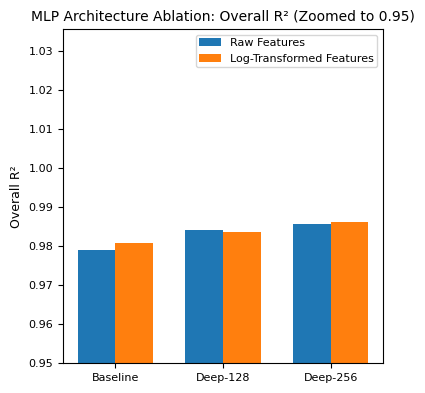

In [87]:
#| label: fig-mlp-architecture-ablation-r2
#| fig-cap: "Overall R² for the MLP architecture ablation study across baseline, deep-128, and deep-256 variants using standardized raw and log-transformed features."

plot_r2_df = architecture_results_df[
    ["Architecture", "Feature Pipeline", "Overall R²"]
].copy()

raw_r2 = [
    plot_r2_df[
        (plot_r2_df["Architecture"] == arch) &
        (plot_r2_df["Feature Pipeline"] == "Raw Features")
    ]["Overall R²"].iloc[0]
    for arch in architectures
]

log_r2 = [
    plot_r2_df[
        (plot_r2_df["Architecture"] == arch) &
        (plot_r2_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Overall R²"].iloc[0]
    for arch in architectures
]

plt.figure(figsize=(4, 4))
plt.bar(x - width/2, raw_r2, width, label="Raw Features")
plt.bar(x + width/2, log_r2, width, label="Log-Transformed Features")

plt.xticks(x, architectures)
plt.ylabel("Overall R²")
plt.title("MLP Architecture Ablation: Overall R² (Zoomed to 0.95)")
plt.ylim(0.95)
plt.legend()
plt.tight_layout()
plt.show()

Across architectures, the improvement from increasing network capacity is substantially larger than the difference between feature representations, indicating that **model architecture plays a more dominant role in predictive accuracy than feature scaling alone**.

The final architectural comparison of models confirms these observations (@tbl-mlp-architecture-best). Both pipelines achieve their best performance with the **Deep-256 architecture**, which contains approximately 47,716 trainable parameters. Among the two pipelines, the **log-transformed feature representation paired with the Deep-256 architecture produces the lowest overall RMSE (0.0337) and highest R² (0.9863)**, making it the strongest configuration in the architecture ablation.

In [81]:
#| label: tbl-mlp-architecture-best
#| tbl-cap: "Best-performing MLP architecture within each feature pipeline based on lowest overall RMSE on the validation set."

best_by_pipeline = (
    architecture_results_df.sort_values("Overall RMSE")
    .groupby("Feature Pipeline", as_index=False)
    .first()[["Feature Pipeline", "Architecture", "Hidden Dimensions", "Trainable Parameters", "Overall RMSE", "Overall R²"]]
    .copy()
)

best_by_pipeline["Overall RMSE"] = best_by_pipeline["Overall RMSE"].round(6)
best_by_pipeline["Overall R²"] = best_by_pipeline["Overall R²"].round(6)

display(best_by_pipeline.style.hide(axis="index"))

Feature Pipeline,Architecture,Hidden Dimensions,Trainable Parameters,Overall RMSE,Overall R²
Log-Transformed Features,Deep-256,"[256, 128, 64, 32]",47716,0.033744,0.986330
Raw Features,Deep-256,"[256, 128, 64, 32]",47716,0.034361,0.985825


From a modeling perspective, these results suggest that county-level SVI prediction benefits from **moderately deep neural networks capable of representing complex nonlinear feature interactions**. The Deep-256 architecture is therefore selected as the preferred MLP configuration for subsequent experiments and regularization analysis.

## Regularization Ablation

The last ablation study was conducted to examine the impact of regularization on model generalization. Two forms of regularization were evaluated independently: **dropout** and **weight decay**. In both experiments the architecture, optimizer, and training schedule were held fixed to isolate the effect of the regularization mechanism itself.

### Dropout Ablation

The first experiment evaluated the effect of **dropout strength** within the Deep-256 network. Three dropout values were tested—**0.0, 0.1, and 0.3** while keeping all other training settings constant (@tbl-mlp-dropout-ablation-config). Each configuration was trained using both the raw and log-transformed pipeline.

In [88]:
#| label: tbl-mlp-dropout-ablation-config
#| tbl-cap: "Dropout configurations used in the MLP regularization ablation study. The Deep-256 architecture is held fixed while dropout strength is varied to evaluate its effect on generalization for both standardized raw and log-transformed features."

dropout_configs = [0.0, 0.1, 0.3]
dropout_hidden_dims = [256, 128, 64, 32]

dropout_config_df = pd.DataFrame({
    "Setting": [
        "Architecture",
        "Dropout Values",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        str(dropout_hidden_dims),
        str(dropout_configs),
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(dropout_config_df.style.hide(axis="index"))

Setting,Value
Architecture,"[256, 128, 64, 32]"
Dropout Values,"[0.0, 0.1, 0.3]"
Learning Rate,0.001000
Weight Decay,0.000100
Max Epochs,300
Early Stopping Patience,25


In [89]:
dropout_results = []

for dropout_value in dropout_configs:
    for feature_name, X_train_tensor, train_loader, val_loader in [
        ("Raw Features", Xraw_train_t, train_loader_raw, val_loader_raw),
        ("Log-Transformed Features", Xlog_train_t, train_loader_log, val_loader_log),
    ]:
        set_seed(SEED)

        model = FlexibleMLP(
            input_dim=X_train_tensor.shape[1],
            hidden_dims=dropout_hidden_dims,
            output_dim=y_train_t.shape[1],
            dropout=dropout_value,
        )

        optimizer = build_optimizer(
            model=model,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )

        model, history, best_epoch, best_val_loss = train_mlp(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        y_pred_scaled = predict_mlp(model, val_loader, device=device)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_val_scaled)

        overall_metrics = evaluate_regression(y_true, y_pred)
        per_target_metrics = evaluate_regression_per_target(y_true, y_pred, target_names)

        dropout_results.append({
            "Dropout": dropout_value,
            "Feature Pipeline": feature_name,
            "Hidden Dimensions": str(dropout_hidden_dims),
            "Weight Decay": WEIGHT_DECAY,
            "Trainable Parameters": count_parameters(model),
            "Epochs Trained": len(history["epoch"]),
            "Best Epoch": best_epoch,
            "Best Validation Loss": best_val_loss,
            "Overall RMSE": overall_metrics["rmse"],
            "Overall R²": overall_metrics["r2"],
            "RPL_THEME1 RMSE": per_target_metrics["RPL_THEME1"]["rmse"],
            "RPL_THEME1 R²": per_target_metrics["RPL_THEME1"]["r2"],
            "RPL_THEME2 RMSE": per_target_metrics["RPL_THEME2"]["rmse"],
            "RPL_THEME2 R²": per_target_metrics["RPL_THEME2"]["r2"],
            "RPL_THEME3 RMSE": per_target_metrics["RPL_THEME3"]["rmse"],
            "RPL_THEME3 R²": per_target_metrics["RPL_THEME3"]["r2"],
            "RPL_THEME4 RMSE": per_target_metrics["RPL_THEME4"]["rmse"],
            "RPL_THEME4 R²": per_target_metrics["RPL_THEME4"]["r2"],
            "History": history,
            "Model": model
        })

In [90]:
#| label: tbl-mlp-dropout-ablation
#| tbl-cap: "Dropout ablation results for the Deep-256 MLP using standardized raw and log-transformed features. Performance is summarized using overall RMSE and R² on the validation set."
#| output: false

dropout_results_df = pd.DataFrame(dropout_results)

dropout_summary = dropout_results_df[
    [
        "Dropout",
        "Feature Pipeline",
        "Trainable Parameters",
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss",
        "Overall RMSE",
        "Overall R²"
    ]
].copy()

dropout_summary["Best Validation Loss"] = dropout_summary["Best Validation Loss"].round(6)
dropout_summary["Overall RMSE"] = dropout_summary["Overall RMSE"].round(6)
dropout_summary["Overall R²"] = dropout_summary["Overall R²"].round(6)

dropout_summary["Experiment"] = (
    "Dropout=" + dropout_summary["Dropout"].astype(str) +
    " | " + dropout_summary["Feature Pipeline"]
)

dropout_summary = dropout_summary.drop(columns=["Dropout", "Feature Pipeline"])
dropout_summary = dropout_summary.set_index("Experiment").T

display(dropout_summary)

Experiment,Dropout=0.0 | Raw Features,Dropout=0.0 | Log-Transformed Features,Dropout=0.1 | Raw Features,Dropout=0.1 | Log-Transformed Features,Dropout=0.3 | Raw Features,Dropout=0.3 | Log-Transformed Features
Trainable Parameters,47716.000000,47716.000000,47716.000000,47716.000000,47716.000000,47716.000000
Epochs Trained,300.000000,300.000000,221.000000,300.000000,119.000000,137.000000
Best Epoch,298.000000,279.000000,196.000000,292.000000,94.000000,112.000000
Best Validation Loss,0.005840,0.004513,0.014076,0.013571,0.044762,0.043193
Overall RMSE,0.022145,0.019460,0.034361,0.033744,0.061265,0.060161
Overall R²,0.994112,0.995453,0.985825,0.986330,0.954938,0.956547


In [91]:
#| label: tbl-mlp-dropout-ablation-per-theme
#| tbl-cap: "Per-theme performance for the MLP dropout ablation study using the Deep-256 architecture with standardized raw and log-transformed features. Metrics are reported as RMSE and R² for each SVI theme."
#| output: false

dropout_per_theme = dropout_results_df[
    [
        "Dropout",
        "Feature Pipeline",
        "RPL_THEME1 RMSE", "RPL_THEME1 R²",
        "RPL_THEME2 RMSE", "RPL_THEME2 R²",
        "RPL_THEME3 RMSE", "RPL_THEME3 R²",
        "RPL_THEME4 RMSE", "RPL_THEME4 R²",
    ]
].copy()

for col in dropout_per_theme.columns:
    if "RMSE" in col or "R²" in col:
        dropout_per_theme[col] = dropout_per_theme[col].round(6)

dropout_per_theme["Experiment"] = (
    "Dropout=" + dropout_per_theme["Dropout"].astype(str) +
    " | " + dropout_per_theme["Feature Pipeline"]
)

dropout_per_theme = dropout_per_theme.drop(columns=["Dropout", "Feature Pipeline"])
dropout_per_theme = dropout_per_theme.set_index("Experiment").T

display(dropout_per_theme)

Experiment,Dropout=0.0 | Raw Features,Dropout=0.0 | Log-Transformed Features,Dropout=0.1 | Raw Features,Dropout=0.1 | Log-Transformed Features,Dropout=0.3 | Raw Features,Dropout=0.3 | Log-Transformed Features
RPL_THEME1 RMSE,0.014924,0.014282,0.029080,0.029015,0.053979,0.059462
RPL_THEME1 R²,0.997320,0.997546,0.989825,0.989871,0.964940,0.957456
RPL_THEME2 RMSE,0.031590,0.026451,0.043937,0.043581,0.074967,0.069755
RPL_THEME2 R²,0.987544,0.991267,0.975905,0.976294,0.929853,0.939268
RPL_THEME3 RMSE,0.011161,0.011370,0.024868,0.024441,0.049065,0.046774
RPL_THEME3 R²,0.998510,0.998454,0.992602,0.992854,0.971203,0.973829
RPL_THEME4 RMSE,0.024826,0.021952,0.036445,0.034871,0.063814,0.062354
RPL_THEME4 R²,0.992863,0.994420,0.984618,0.985918,0.952841,0.954974


The results show a clear relationship between dropout strength and predictive performance. As illustrated in the RMSE comparison (@fig-mlp-dropout-ablation-rmse), **prediction error increases as dropout strength increases**. The lowest RMSE occurs when **dropout is disabled (0.0)** for both feature pipelines. Moderate dropout (0.1) slightly increases error, while stronger dropout (0.3) leads to a substantial degradation in performance.

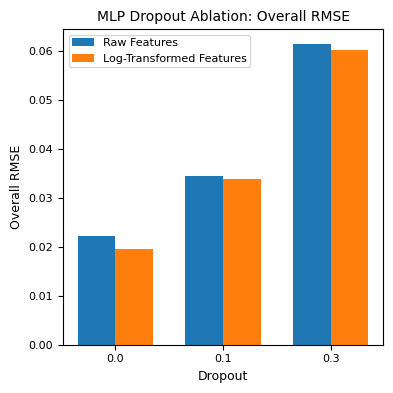

In [92]:
#| label: fig-mlp-dropout-ablation-rmse
#| fig-cap: "Overall RMSE for the MLP dropout ablation study using the Deep-256 architecture across multiple dropout strengths for standardized raw and log-transformed features. Lower values indicate better predictive accuracy."

dropout_plot_rmse_df = dropout_results_df[
    ["Dropout", "Feature Pipeline", "Overall RMSE"]
].copy()

dropout_values = dropout_configs
x = np.arange(len(dropout_values))
width = 0.35

raw_rmse = [
    dropout_plot_rmse_df[
        (dropout_plot_rmse_df["Dropout"] == d) &
        (dropout_plot_rmse_df["Feature Pipeline"] == "Raw Features")
    ]["Overall RMSE"].iloc[0]
    for d in dropout_values
]

log_rmse = [
    dropout_plot_rmse_df[
        (dropout_plot_rmse_df["Dropout"] == d) &
        (dropout_plot_rmse_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Overall RMSE"].iloc[0]
    for d in dropout_values
]

plt.figure(figsize=(4, 4))
plt.bar(x - width/2, raw_rmse, width, label="Raw Features")
plt.bar(x + width/2, log_rmse, width, label="Log-Transformed Features")

plt.xticks(x, [str(d) for d in dropout_values])
plt.xlabel("Dropout")
plt.ylabel("Overall RMSE")
plt.title("MLP Dropout Ablation: Overall RMSE")
plt.legend()
plt.tight_layout()
plt.show()

As expected, the R² comparison (@fig-mlp-dropout-ablation-r2) shows the same pattern. Models trained without dropout achieve the highest explanatory power, while stronger dropout values progressively reduce the variance explained by the model.

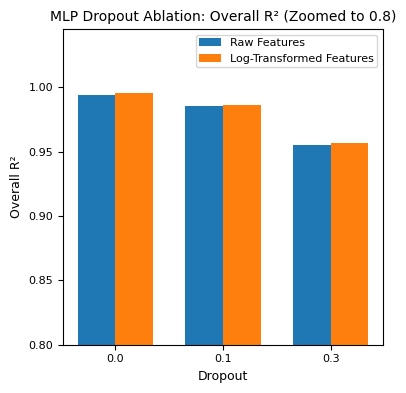

In [98]:
#| label: fig-mlp-dropout-ablation-r2
#| fig-cap: "Overall R² for the MLP dropout ablation study using the Deep-256 architecture across multiple dropout strengths for standardized raw EP_* features and standardized log-transformed EP_* features."

dropout_plot_r2_df = dropout_results_df[
    ["Dropout", "Feature Pipeline", "Overall R²"]
].copy()

raw_r2 = [
    dropout_plot_r2_df[
        (dropout_plot_r2_df["Dropout"] == d) &
        (dropout_plot_r2_df["Feature Pipeline"] == "Raw Features")
    ]["Overall R²"].iloc[0]
    for d in dropout_values
]

log_r2 = [
    dropout_plot_r2_df[
        (dropout_plot_r2_df["Dropout"] == d) &
        (dropout_plot_r2_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Overall R²"].iloc[0]
    for d in dropout_values
]

plt.figure(figsize=(4, 4))
plt.bar(x - width/2, raw_r2, width, label="Raw Features")
plt.bar(x + width/2, log_r2, width, label="Log-Transformed Features")

plt.xticks(x, [str(d) for d in dropout_values])
plt.xlabel("Dropout")
plt.ylabel("Overall R²")
plt.title("MLP Dropout Ablation: Overall R² (Zoomed to 0.8)")
plt.ylim(0.8)
plt.legend()
plt.tight_layout()
plt.show()

The best-performing configuration from the dropout ablation is therefore the **Deep-256 architecture with dropout = 0.0**, as summarized in @tbl-mlp-dropout-best. This result suggests that the dataset size and feature structure provide sufficient signal to train the network without requiring dropout-based regularization.

In [99]:
#| label: tbl-mlp-dropout-best
#| tbl-cap: "Best-performing dropout setting within each feature pipeline for the Deep-256 MLP based on lowest overall RMSE on the validation set."

best_dropout_by_pipeline = (
    dropout_results_df.sort_values("Overall RMSE")
    .groupby("Feature Pipeline", as_index=False)
    .first()[["Feature Pipeline", "Dropout", "Overall RMSE", "Overall R²", "Best Validation Loss", "Best Epoch"]]
    .copy()
)

best_dropout_by_pipeline["Overall RMSE"] = best_dropout_by_pipeline["Overall RMSE"].round(6)
best_dropout_by_pipeline["Overall R²"] = best_dropout_by_pipeline["Overall R²"].round(6)
best_dropout_by_pipeline["Best Validation Loss"] = best_dropout_by_pipeline["Best Validation Loss"].round(6)

display(best_dropout_by_pipeline.style.hide(axis="index"))

Feature Pipeline,Dropout,Overall RMSE,Overall R²,Best Validation Loss,Best Epoch
Log-Transformed Features,0.000000,0.019460,0.995453,0.004513,279
Raw Features,0.000000,0.022145,0.994112,0.005840,298


### Weight Decay Ablation

After determining that dropout was unnecessary, the second regularization experiment evaluated **L2 weight decay** while keeping dropout fixed at **0.0**. Three weight decay values were tested—**0.0, 1e-3, and 1e-5**—using the same architecture and training settings (@tbl-mlp-weight-decay-ablation-config).

In [100]:
#| label: tbl-mlp-weight-decay-ablation-config
#| tbl-cap: "Weight decay configurations used in the MLP regularization ablation study. The Deep-256 architecture and zero-dropout setting are held fixed while weight decay is varied to evaluate its effect on generalization for both standardized raw and log-transformed features."

weight_decay_configs = [0.0, 1e-3, 1e-5]
weight_decay_hidden_dims = [256, 128, 64, 32]
best_dropout = 0.0

weight_decay_config_df = pd.DataFrame({
    "Setting": [
        "Architecture",
        "Dropout",
        "Weight Decay Values",
        "Learning Rate",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        str(weight_decay_hidden_dims),
        best_dropout,
        str(weight_decay_configs),
        LEARNING_RATE,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(weight_decay_config_df.style.hide(axis="index"))

Setting,Value
Architecture,"[256, 128, 64, 32]"
Dropout,0.000000
Weight Decay Values,"[0.0, 0.001, 1e-05]"
Learning Rate,0.001000
Max Epochs,300
Early Stopping Patience,25


In [107]:
weight_decay_results = []

for weight_decay_value in weight_decay_configs:
    for feature_name, X_train_tensor, train_loader, val_loader in [
        ("Raw Features", Xraw_train_t, train_loader_raw, val_loader_raw),
        ("Log-Transformed Features", Xlog_train_t, train_loader_log, val_loader_log),
    ]:
        set_seed(SEED)

        model = FlexibleMLP(
            input_dim=X_train_tensor.shape[1],
            hidden_dims=weight_decay_hidden_dims,
            output_dim=y_train_t.shape[1],
            dropout=best_dropout,
        )

        optimizer = build_optimizer(
            model=model,
            learning_rate=LEARNING_RATE,
            weight_decay=weight_decay_value,
        )

        model, history, best_epoch, best_val_loss = train_mlp(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        y_pred_scaled = predict_mlp(model, val_loader, device=device)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_val_scaled)

        overall_metrics = evaluate_regression(y_true, y_pred)
        per_target_metrics = evaluate_regression_per_target(y_true, y_pred, target_names)

        weight_decay_results.append({
            "Weight Decay": weight_decay_value,
            "Feature Pipeline": feature_name,
            "Hidden Dimensions": str(weight_decay_hidden_dims),
            "Dropout": best_dropout,
            "Trainable Parameters": count_parameters(model),
            "Epochs Trained": len(history["epoch"]),
            "Best Epoch": best_epoch,
            "Best Validation Loss": best_val_loss,
            "Overall RMSE": overall_metrics["rmse"],
            "Overall R²": overall_metrics["r2"],
            "RPL_THEME1 RMSE": per_target_metrics["RPL_THEME1"]["rmse"],
            "RPL_THEME1 R²": per_target_metrics["RPL_THEME1"]["r2"],
            "RPL_THEME2 RMSE": per_target_metrics["RPL_THEME2"]["rmse"],
            "RPL_THEME2 R²": per_target_metrics["RPL_THEME2"]["r2"],
            "RPL_THEME3 RMSE": per_target_metrics["RPL_THEME3"]["rmse"],
            "RPL_THEME3 R²": per_target_metrics["RPL_THEME3"]["r2"],
            "RPL_THEME4 RMSE": per_target_metrics["RPL_THEME4"]["rmse"],
            "RPL_THEME4 R²": per_target_metrics["RPL_THEME4"]["r2"],
            "History": history,
            "Model": model
        })

In [108]:
#| label: tbl-mlp-weight-decay-ablation
#| tbl-cap: "Weight decay ablation results for the Deep-256 MLP with zero dropout using standardized raw and log-transformed features. Performance is summarized using overall RMSE and R² on the validation set."
#| output: false

weight_decay_results_df = pd.DataFrame(weight_decay_results)

weight_decay_summary = weight_decay_results_df[
    [
        "Weight Decay",
        "Feature Pipeline",
        "Trainable Parameters",
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss",
        "Overall RMSE",
        "Overall R²"
    ]
].copy()

weight_decay_summary["Best Validation Loss"] = weight_decay_summary["Best Validation Loss"].round(6)
weight_decay_summary["Overall RMSE"] = weight_decay_summary["Overall RMSE"].round(6)
weight_decay_summary["Overall R²"] = weight_decay_summary["Overall R²"].round(6)

weight_decay_summary["Experiment"] = (
    "WD=" + weight_decay_summary["Weight Decay"].astype(str) +
    " | " + weight_decay_summary["Feature Pipeline"]
)

weight_decay_summary = weight_decay_summary.drop(columns=["Weight Decay", "Feature Pipeline"])
weight_decay_summary = weight_decay_summary.set_index("Experiment").T

display(weight_decay_summary)

Experiment,WD=0.0 | Raw Features,WD=0.0 | Log-Transformed Features,WD=0.001 | Raw Features,WD=0.001 | Log-Transformed Features,WD=1e-05 | Raw Features,WD=1e-05 | Log-Transformed Features
Trainable Parameters,47716.000000,47716.000000,47716.000000,47716.000000,47716.000000,47716.000000
Epochs Trained,180.000000,275.000000,214.000000,188.000000,296.000000,300.000000
Best Epoch,155.000000,250.000000,189.000000,163.000000,271.000000,282.000000
Best Validation Loss,0.009529,0.006838,0.005540,0.005757,0.008395,0.006661
Overall RMSE,0.028288,0.023947,0.021565,0.021975,0.026555,0.023638
Overall R²,0.990393,0.993115,0.994417,0.994202,0.991534,0.993292


In [109]:
#| label: tbl-mlp-weight-decay-ablation-per-theme
#| tbl-cap: "Per-theme performance for the MLP weight decay ablation study using the Deep-256 architecture with zero dropout and standardized raw and log-transformed features. Metrics are reported as RMSE and R² for each SVI theme."
#| output: false

weight_decay_per_theme = weight_decay_results_df[
    [
        "Weight Decay",
        "Feature Pipeline",
        "RPL_THEME1 RMSE", "RPL_THEME1 R²",
        "RPL_THEME2 RMSE", "RPL_THEME2 R²",
        "RPL_THEME3 RMSE", "RPL_THEME3 R²",
        "RPL_THEME4 RMSE", "RPL_THEME4 R²",
    ]
].copy()

for col in weight_decay_per_theme.columns:
    if "RMSE" in col or "R²" in col:
        weight_decay_per_theme[col] = weight_decay_per_theme[col].round(6)

weight_decay_per_theme["Experiment"] = (
    "WD=" + weight_decay_per_theme["Weight Decay"].astype(str) +
    " | " + weight_decay_per_theme["Feature Pipeline"]
)

weight_decay_per_theme = weight_decay_per_theme.drop(columns=["Weight Decay", "Feature Pipeline"])
weight_decay_per_theme = weight_decay_per_theme.set_index("Experiment").T

display(weight_decay_per_theme)

Experiment,WD=0.0 | Raw Features,WD=0.0 | Log-Transformed Features,WD=0.001 | Raw Features,WD=0.001 | Log-Transformed Features,WD=1e-05 | Raw Features,WD=1e-05 | Log-Transformed Features
RPL_THEME1 RMSE,0.020570,0.018873,0.017351,0.019927,0.018673,0.017467
RPL_THEME1 R²,0.994909,0.995714,0.996378,0.995222,0.995805,0.996329
RPL_THEME2 RMSE,0.039951,0.031339,0.029466,0.028337,0.038073,0.031485
RPL_THEME2 R²,0.980079,0.987741,0.989163,0.989977,0.981907,0.987627
RPL_THEME3 RMSE,0.014929,0.013789,0.012952,0.013957,0.014071,0.013731
RPL_THEME3 R²,0.997334,0.997726,0.997993,0.997670,0.997631,0.997745
RPL_THEME4 RMSE,0.030962,0.027663,0.022874,0.023168,0.028713,0.027388
RPL_THEME4 R²,0.988898,0.991138,0.993941,0.993784,0.990453,0.991313


The RMSE results show that **moderate weight decay improves model performance**, particularly for the log-transformed feature pipeline (@fig-mlp-weight-decay-ablation-rmse). Models trained without weight decay produce the largest prediction error, while introducing L2 regularization reduces RMSE. Among the tested values, **weight decay = 0.001 yields the lowest error across both pipelines**.

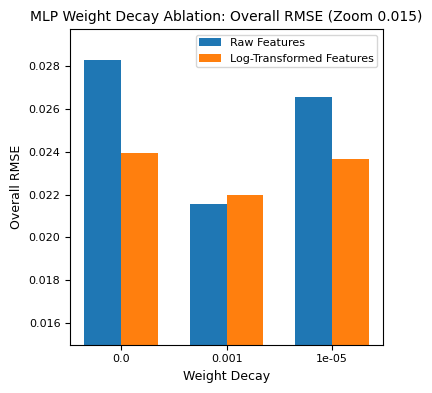

In [110]:
#| label: fig-mlp-weight-decay-ablation-rmse
#| fig-cap: "Overall RMSE for the MLP weight decay ablation study using the Deep-256 architecture with zero dropout across multiple weight decay strengths for standardized raw and log-transformed features. Lower values indicate better predictive accuracy."

weight_decay_plot_rmse_df = weight_decay_results_df[
    ["Weight Decay", "Feature Pipeline", "Overall RMSE"]
].copy()

wd_values = weight_decay_configs
x = np.arange(len(wd_values))
width = 0.35

raw_rmse = [
    weight_decay_plot_rmse_df[
        (weight_decay_plot_rmse_df["Weight Decay"] == wd) &
        (weight_decay_plot_rmse_df["Feature Pipeline"] == "Raw Features")
    ]["Overall RMSE"].iloc[0]
    for wd in wd_values
]

log_rmse = [
    weight_decay_plot_rmse_df[
        (weight_decay_plot_rmse_df["Weight Decay"] == wd) &
        (weight_decay_plot_rmse_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Overall RMSE"].iloc[0]
    for wd in wd_values
]

plt.figure(figsize=(4, 4))
plt.bar(x - width/2, raw_rmse, width, label="Raw Features")
plt.bar(x + width/2, log_rmse, width, label="Log-Transformed Features")

plt.xticks(x, [str(wd) for wd in wd_values])
plt.xlabel("Weight Decay")
plt.ylabel("Overall RMSE")
plt.title("MLP Weight Decay Ablation: Overall RMSE (Zoom 0.015)")
plt.ylim(0.015)
plt.legend()
plt.tight_layout()
plt.show()

The R² comparison reveals a similar trend (@fig-mlp-weight-decay-ablation-r2). While the differences are relatively small due to the already strong predictive performance of the model, weight decay improves the model’s ability to generalize to unseen counties by slightly increasing the variance explained on the validation set.

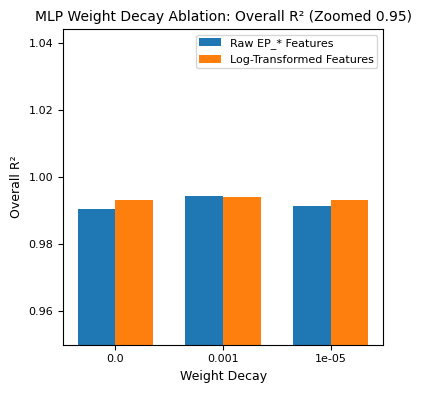

In [112]:
#| label: fig-mlp-weight-decay-ablation-r2
#| fig-cap: "Overall R² for the MLP weight decay ablation study using the Deep-256 architecture with zero dropout across multiple weight decay strengths for standardized raw and log-transformed features."

weight_decay_plot_r2_df = weight_decay_results_df[
    ["Weight Decay", "Feature Pipeline", "Overall R²"]
].copy()

raw_r2 = [
    weight_decay_plot_r2_df[
        (weight_decay_plot_r2_df["Weight Decay"] == wd) &
        (weight_decay_plot_r2_df["Feature Pipeline"] == "Raw Features")
    ]["Overall R²"].iloc[0]
    for wd in wd_values
]

log_r2 = [
    weight_decay_plot_r2_df[
        (weight_decay_plot_r2_df["Weight Decay"] == wd) &
        (weight_decay_plot_r2_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Overall R²"].iloc[0]
    for wd in wd_values
]

plt.figure(figsize=(4, 4))
plt.bar(x - width/2, raw_r2, width, label="Raw EP_* Features")
plt.bar(x + width/2, log_r2, width, label="Log-Transformed Features")

plt.xticks(x, [str(wd) for wd in wd_values])
plt.xlabel("Weight Decay")
plt.ylabel("Overall R²")
plt.title("MLP Weight Decay Ablation: Overall R² (Zoomed 0.95)")
plt.ylim(0.95)
plt.legend()
plt.tight_layout()
plt.show()

The best configuration from this experiment is therefore the **Deep-256 architecture with dropout = 0.0 and weight decay = 0.001**, as summarized in @tbl-mlp-weight-decay-best. This setting provides the best balance between model flexibility and parameter regularization.

In [113]:
#| label: tbl-mlp-weight-decay-best
#| tbl-cap: "Best-performing weight decay setting within each feature pipeline for the Deep-256 MLP with zero dropout based on lowest overall RMSE on the validation set."

best_weight_decay_by_pipeline = (
    weight_decay_results_df.sort_values("Overall RMSE")
    .groupby("Feature Pipeline", as_index=False)
    .first()[["Feature Pipeline", "Weight Decay", "Overall RMSE", "Overall R²", "Best Validation Loss", "Best Epoch"]]
    .copy()
)

best_weight_decay_by_pipeline["Overall RMSE"] = best_weight_decay_by_pipeline["Overall RMSE"].round(6)
best_weight_decay_by_pipeline["Overall R²"] = best_weight_decay_by_pipeline["Overall R²"].round(6)
best_weight_decay_by_pipeline["Best Validation Loss"] = best_weight_decay_by_pipeline["Best Validation Loss"].round(6)

display(best_weight_decay_by_pipeline.style.hide(axis="index"))

Feature Pipeline,Weight Decay,Overall RMSE,Overall R²,Best Validation Loss,Best Epoch
Log-Transformed Features,0.001000,0.021975,0.994202,0.005757,163
Raw Features,0.001000,0.021565,0.994417,0.005540,189


Together, this set of experiments indicate that **regularization affects the model primarily through weight decay rather than dropout**. The network performs best without dropout, suggesting that the dataset is sufficiently large relative to the model size to avoid severe overfitting. However, moderate L2 regularization still provides a measurable improvement by constraining parameter magnitude and improving generalization stability.

After the ablation experiments, the final MLP configuration used for evaluation against the validation set combines log-transformed indicators, the **Deep-256 architecture, no dropout, and weight decay of 0.001**. As shown in @tbl-mlp-best-config-summary, this configuration achieves the lowest average RMSE across the four theme targets (**validation RMSE = 0.0220**) and the highest explanatory power (**validation R² = 0.9942**) among the tested models.

In [120]:
#| label: tbl-mlp-best-config-summary
#| tbl-cap: "Best-performing MLP configuration identified from the architecture and regularization ablations. The selected model uses log-transformed features with the Deep-256 architecture, zero dropout, and weight decay of 0.001. Metrics shown here are validation-set results used for model selection."

best_mlp_row = (
    weight_decay_results_df[
        weight_decay_results_df["Feature Pipeline"] == "Log-Transformed Features"
    ]
    .sort_values(["Overall RMSE", "Best Validation Loss"], ascending=[True, True])
    .iloc[0]
)

best_mlp_config = pd.DataFrame({
    "Metric": [
        "Feature Representation",
        "Architecture (Hidden Dimensions)",
        "Dropout",
        "Weight Decay",
        "Best Validation Epoch",
        "Best Validation Loss",
        "Overall RMSE",
        "Overall R²",
        "RPL_THEME1 RMSE",
        "RPL_THEME1 R²",
        "RPL_THEME2 RMSE",
        "RPL_THEME2 R²",
        "RPL_THEME3 RMSE",
        "RPL_THEME3 R²",
        "RPL_THEME4 RMSE",
        "RPL_THEME4 R²"
    ],
    "Value": [
        best_mlp_row["Feature Pipeline"],
        best_mlp_row["Hidden Dimensions"],
        round(best_mlp_row["Dropout"], 6),
        round(best_mlp_row["Weight Decay"], 6),
        int(best_mlp_row["Best Epoch"]),
        round(best_mlp_row["Best Validation Loss"], 6),
        round(best_mlp_row["Overall RMSE"], 6),
        round(best_mlp_row["Overall R²"], 6),
        round(best_mlp_row["RPL_THEME1 RMSE"], 6),
        round(best_mlp_row["RPL_THEME1 R²"], 6),
        round(best_mlp_row["RPL_THEME2 RMSE"], 6),
        round(best_mlp_row["RPL_THEME2 R²"], 6),
        round(best_mlp_row["RPL_THEME3 RMSE"], 6),
        round(best_mlp_row["RPL_THEME3 R²"], 6),
        round(best_mlp_row["RPL_THEME4 RMSE"], 6),
        round(best_mlp_row["RPL_THEME4 R²"], 6)
    ]
})

display(best_mlp_config.style.hide(axis="index"))

Metric,Value
Feature Representation,Log-Transformed Features
Architecture (Hidden Dimensions),"[256, 128, 64, 32]"
Dropout,0.000000
Weight Decay,0.001000
Best Validation Epoch,163
Best Validation Loss,0.005757
Overall RMSE,0.021975
Overall R²,0.994202
RPL_THEME1 RMSE,0.019927
RPL_THEME1 R²,0.995222


## MLP Summary

Because the SVI theme percentile tagets are derived from the same underlying EP_* indicators used as predictors, these results should be interpreted with care. The strong performance in @tbl-final-mlp-test-evaluation therefore reflects **the model’s ability to learn the nonlinear mapping from the socioeconomic input variables to the published SVI percentile-based theme rankings**, rather than the discovery of entirely independent drivers of vulnerability. In that sense, the MLP is best understood as approximating the transformation embedded in the SVI construction process.

The final held-out test results remain strong overall, with an **overall RMSE of 0.0226** and **overall R² of 0.9937** (@tbl-final-mlp-test-evaluation). The per-theme breakdown in @fig-mlp-best-per-theme-combined shows that Theme 3 (Minority Status) is predicted most accurately, achieving the **lowest RMSE (0.014371)** and **highest R² (0.997529)**. Theme 1 (Socioeconomic Status) also performs very well, with **RMSE = 0.020721** and **R² = 0.994857**, consistent with the close relationship between the input indicators and socioeconomic deprivation measures. Theme 4 (Housing and Transportation) remains highly predictable as well, although its error is modestly higher (**RMSE = 0.022873**, **R² = 0.993613**). Among the four targets, Theme 2 (Household Characteristics) is the most difficult, with the **highest RMSE (0.029879)** and **lowest R² (0.988840)**, suggesting that household composition and dependency-related structure is comparatively harder for the tabular MLP to recover. Overall, these results indicate that the selected MLP captures the official SVI theme relationships very effectively, but the high predictive performance should be interpreted in light of the strong structural overlap between the **RPL theme targets** and the **EP feature inputs**.


In [115]:
#| label: tbl-final-mlp-test-evaluation
#| tbl-cap: "Final held-out test-set performance for the selected MLP configuration using log-transformed features."

target_names = ["RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]

# Final selected configuration from validation ablations
final_hidden_dims = [256, 128, 64, 32]
final_dropout = 0.0
final_weight_decay = 0.001

set_seed(SEED)

# Rebuild final model
final_mlp = FlexibleMLP(
    input_dim=Xlog_train_t.shape[1],
    hidden_dims=final_hidden_dims,
    output_dim=y_train_t.shape[1],
    dropout=final_dropout,
)

final_optimizer = build_optimizer(
    model=final_mlp,
    learning_rate=LEARNING_RATE,
    weight_decay=final_weight_decay,
)

# Train final model using the same train/validation protocol
final_mlp, final_history, final_best_epoch, final_best_val = train_mlp(
    model=final_mlp,
    train_loader=train_loader_log,
    val_loader=val_loader_log,
    criterion=criterion,
    optimizer=final_optimizer,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=device,
)

# Final one-time evaluation on the held-out test split
y_test_pred_scaled = predict_mlp(final_mlp, test_loader_log, device=device)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_true = scaler_y.inverse_transform(y_test_scaled)

overall_test = evaluate_regression(y_test_true, y_test_pred)
per_target_test = evaluate_regression_per_target(
    y_test_true,
    y_test_pred,
    target_names
)

final_mlp_test_summary = pd.DataFrame({
    "Metric": [
        "Feature Representation",
        "Architecture (Hidden Dimensions)",
        "Dropout",
        "Weight Decay",
        "Best Validation Epoch",
        "Best Validation Loss",
        "Overall RMSE",
        "Overall R²",
        "RPL_THEME1 RMSE",
        "RPL_THEME1 R²",
        "RPL_THEME2 RMSE",
        "RPL_THEME2 R²",
        "RPL_THEME3 RMSE",
        "RPL_THEME3 R²",
        "RPL_THEME4 RMSE",
        "RPL_THEME4 R²"
    ],
    "Value": [
        "Log-Transformed EP_* Features",
        str(final_hidden_dims),
        final_dropout,
        final_weight_decay,
        final_best_epoch,
        round(final_best_val, 6),
        round(overall_test["rmse"], 6),
        round(overall_test["r2"], 6),
        round(per_target_test["RPL_THEME1"]["rmse"], 6),
        round(per_target_test["RPL_THEME1"]["r2"], 6),
        round(per_target_test["RPL_THEME2"]["rmse"], 6),
        round(per_target_test["RPL_THEME2"]["r2"], 6),
        round(per_target_test["RPL_THEME3"]["rmse"], 6),
        round(per_target_test["RPL_THEME3"]["r2"], 6),
        round(per_target_test["RPL_THEME4"]["rmse"], 6),
        round(per_target_test["RPL_THEME4"]["r2"], 6),
    ]
})

display(final_mlp_test_summary.style.hide(axis="index"))

Metric,Value
Feature Representation,Log-Transformed EP_* Features
Architecture (Hidden Dimensions),"[256, 128, 64, 32]"
Dropout,0.000000
Weight Decay,0.001000
Best Validation Epoch,163
Best Validation Loss,0.005757
Overall RMSE,0.022648
Overall R²,0.993763
RPL_THEME1 RMSE,0.020721
RPL_THEME1 R²,0.994857


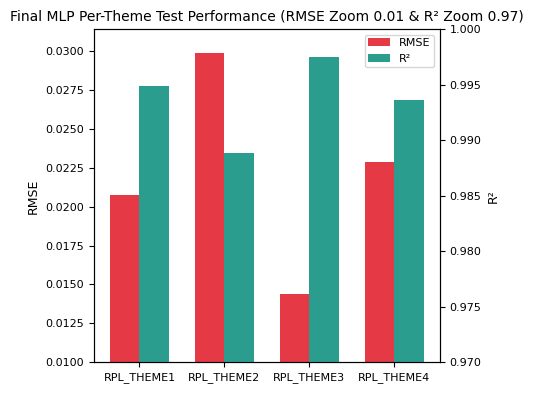

In [119]:
#| label: fig-mlp-best-per-theme-combined
#| fig-cap: "Per-theme RMSE and R² on the held-out test set for the final MLP configuration using log-transformed EP_* features, the Deep-256 architecture, zero dropout, and weight decay of 0.001. RMSE is shown on the left axis and R² on the right axis."

themes = ["RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]
x = np.arange(len(themes))
width = 0.35

# Use final test evaluation results
rmse_vals = [per_target_test[t]["rmse"] for t in themes]
r2_vals = [per_target_test[t]["r2"] for t in themes]

fig, ax1 = plt.subplots(figsize=(5, 4))

bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(themes)
ax1.set_title("Final MLP Per-Theme Test Performance (RMSE Zoom 0.01 & R² Zoom 0.97)")
ax1.set_ylim(0.01)
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="R²",
    color="#2a9d8f"
)

ax2.set_ylabel("R²")
ax2.set_ylim(0.97, 1.0)

handles = [bars1, bars2]
labels = ["RMSE", "R²"]
ax1.legend(handles, labels, loc="upper right")

fig.tight_layout()
plt.show()

Overall, the final MLP demonstrates that a carefully tuned neural network can achieve highly accurate predictions using only tabular county-level indicators. However, the model still treats counties as **independent observations**, ignoring the spatial relationships between neighboring communities. Because social vulnerability often exhibits strong geographic clustering as we observed in our EDA, incorporating spatial structure may provide additional predictive signal. This motivates the transition to **graph-based models**, which explicitly represent counties as nodes within a spatial network and allow neighboring regions to influence each other during learning.

In [121]:
#| output: false

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

artifact_dir = Path("../data/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    processed_dir / "svi_processed_splits.npz",

    # Raw feature pipeline
    X_train_scaled=X_train_scaled,
    X_val_scaled=X_val_scaled,
    X_test_scaled=X_test_scaled,

    # Log feature pipeline
    Xlog_train_scaled=Xlog_train_scaled,
    Xlog_val_scaled=Xlog_val_scaled,
    Xlog_test_scaled=Xlog_test_scaled,

    # Targets
    y_train_scaled=y_train_scaled,
    y_val_scaled=y_val_scaled,
    y_test_scaled=y_test_scaled,

    # County identifiers
    fips_train=fips_train.astype(str).to_numpy(),
    fips_val=fips_val.astype(str).to_numpy(),
    fips_test=fips_test.astype(str).to_numpy(),
)

# Save scalers for inverting predictions
joblib.dump(scaler_Xlog, processed_dir / "scaler_Xlog.pkl")
joblib.dump(scaler_y, processed_dir / "scaler_y.pkl")

['..\\data\\processed\\scaler_y.pkl']

In [122]:
# Save best MLP configuration and final test performance for later comparisons

best_mlp_config = {

    "feature_pipeline": "log-transformed EP_*",

    "architecture": {
        "model": "MLP",
        "variant": "Deep-256",
        "input_dim": int(Xlog_train.shape[1]),
        "hidden_layers": [256, 128, 64, 32],
        "activation": "ReLU",
        "dropout": 0.0,
        "trainable_parameters": int(count_parameters(final_mlp))
    },

    "regularization": {
        "weight_decay": 0.001
    },

    "training": {
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": PATIENCE,
        "best_epoch": int(final_best_epoch)
    },

    "performance": {
        "evaluation_split": "test",
        "overall_rmse": float(overall_test["rmse"]),
        "overall_r2": float(overall_test["r2"]),
        "per_theme": per_target_test
    }
}

with open(artifact_dir / "best_mlp_config.json", "w") as f:
    json.dump(best_mlp_config, f, indent=4)